In [1]:
import os

repo_dir = os.environ.get("REPO_DIR")
code_dir = os.path.join(repo_dir, "code/")
data_dir = os.path.join(repo_dir, "data/")

os.chdir(code_dir)

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import pickle
import sklearn 
import sys
import pandas as pd
from importlib import reload

from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
import seaborn as sns

from scipy.stats import spearmanr, mode

import geopandas as gpd
import rasterio
import zarr

import gc

import warnings

from mosaiks.utils.imports import *

from mosaiks.utils.io import weighted_groupby
from affine import Affine

import cartopy.crs as ccrs
# Key prediction functions are here
import matplotlib.patheffects as pe
import cartopy.feature as cf

from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


# Super zooms on newly produced data

Like the global maps, replicating these visualizations requires a large number of shapefiles that are not in the GitHub repo.

In [3]:
raster_outpath = (data_dir + "preds/"
           "hdi_raster_predictions.tif")

In [4]:
vmin,vmax = (0.35, 0.84) # More condensed than Fig3

In [5]:
roads = gpd.read_file(data_dir + "raw/basemap_data/stanford-vs175mk0273-geojson.json")
## Roads data from this source: https://maps.princeton.edu/catalog/stanford-vs175mk0273

cities = gpd.read_file(data_dir + "raw/basemap_data/ne_10m_populated_places_simple/ne_10m_populated_places_simple.shp")
## Cities data from Natural Earth (public domain) https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-populated-places/
cities = cities[cities["pop_min"] >= 500_000] # only cities with at least half a million people

In [6]:
countries = pd.read_pickle(data_dir +"int/GDL_HDI/HDI_ADM0_dissolved_shapefile.p")
adm1 = pd.read_pickle(data_dir + "int/GDL_HDI/HDI_ADM1_shapefile_clean.p" )
adm2 = gpd.read_file(data_dir + "raw/geoBoundaries/geoBoundariesCGAZ_ADM2.geojson")
adm2_preds = pd.read_pickle(data_dir+"preds/hdi_preds_at_adm2.p")

raw_countries = pd.read_pickle(data_dir + "/int/" +
                    "GDL_HDI/HDI_indicators_and_indices_clean.p").groupby("ISO_Code")["country"].first()
countries = countries.merge(raw_countries, left_index=True, right_index=True)

/share/software/user/open/python/3.9.0/lib/python3.9/pickle.py:1715: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again; shapely 2.1 will not have this compatibility.
  setstate(state)
/share/software/user/open/python/3.9.0/lib/python3.9/pickle.py:1715: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again; shapely 2.1 will not have this compatibility.
  setstate(state)


In [7]:
arr = rasterio.open(raster_outpath).read(1)

In [8]:
print("n_obs raster:", (~np.isnan(arr)).sum())

n_obs raster: 819309


In [9]:
print("n_obs adm2:", len(adm2_preds.dropna(subset=["adjusted_preds"])))

n_obs adm2: 61530


In [10]:
def make_superzoom(left_bound, right_bound, top_bound, lower_bound, savepath=None):
    if savepath:
        rasterized=True
    else:
        rasterized=False
    
    ### Calculations for scalebar
    points = gpd.GeoSeries([Point(-73.5, (top_bound+lower_bound)/2), Point(-74.5, (top_bound+lower_bound)/2)], crs=4326)  # Geographic WGS 84 - degrees
    points = points.to_crs(32619) # Projected WGS 84 - meters
    distance_meters = points[0].distance(points[1])
    
    fig, ax = plt.subplots(1,2, figsize=(20,13), subplot_kw={"projection" : ccrs.PlateCarree()})

    countries.plot(ax=ax[1], color="lightgrey", zorder=0, rasterized=rasterized,linewidth=4)

    with rasterio.open(raster_outpath) as src:
        rst = src.read(1, window= rasterio.windows.from_bounds(left_bound, lower_bound, right_bound, top_bound, src.transform))
        print(rst.shape)
        print(rst)
    a = ax[1].imshow(rst, interpolation=None,#"nearest",
                  extent = (left_bound,right_bound,lower_bound,top_bound),
                  cmap="plasma", 
                  vmin=vmin, vmax=vmax,
                  zorder=1,
                  )

    ax[1].set_xlim(left_bound, right_bound)
    ax[1].set_ylim(lower_bound, top_bound)


    # Country labels
    for i, row in countries.iterrows():
        x = row["geometry"].centroid.x
        y = row["geometry"].centroid.y
        country = row["country"]
        y_adj = 0
        x_adj= 0
        
        if country == "Bangladesh":
            y_adj= 1
        if country == "Nigeria":
            y_adj= -1
        if country== "Benin":
            y_adj = - 1
            x_adj = -1
        if country == "Togo":
            y_adj = -1.4
            X_adj = -.3
        if country== "Ghana":
            x_adj = -.8
        if country == "Equatorial Guinea":
            continue
        if country == "Dominican Republic":
            x_adj = -.3
        

        if (left_bound < x < right_bound) and (lower_bound < y < top_bound):
            print(row["country"])
            ax[1].text(x+x_adj, y+y_adj, country,
               fontweight = "semibold", size=18, zorder=6, color="grey",
                   path_effects=[pe.withStroke(linewidth=2, foreground="white")])

        
    ## City labels
    for i, row in cities.iterrows():
        x = row["geometry"].x
        y = row["geometry"].y
        city = row["name"]

        if city == "Yaoundé":
            continue
        if city == "Cotonou":
            continue
        if city == "Enugu":
            continue
        if city == "Cuttack":
            continue
        
        if (left_bound < x < right_bound) and (lower_bound < y < top_bound):
            ax[1].text(x+.015, y+.015, city,
              size=13, zorder=5, color="black",fontweight = "semibold",
                   path_effects=[pe.withStroke(linewidth=2, foreground="white")])

            ax[1].scatter(x,y, s=12, color="black", zorder=4,
                       edgecolor='white', linewidth=1)



    ## Adm bounds
    ax[1].add_feature(cf.BORDERS,linewidth=2.2, zorder=2, 
                    rasterized=False, 
               color="black", alpha=.65)
    
    ax[1].add_feature(cf.COASTLINE,linewidth=2.2, zorder=2, 
                rasterized=False, 
           color="black", alpha=.65)
    
    adm1.exterior.plot(ax = ax[1], linewidth=1.2, zorder=2, 
                       rasterized=rasterized, color="black", alpha=.60)
    adm2.boundary.plot(ax = ax[1], linewidth=0.3, zorder=2, 
                       rasterized=rasterized, color="black", alpha=.55)

    ## Roads
    roads.plot(ax=ax[1], marker = "-", color="white", linewidth=1.5,
               zorder=3, alpha=.8, rasterized=rasterized)

    roads.plot(ax=ax[1], linestyle = "--", color="black", linewidth=1.5,
               zorder=3, 
                   alpha=.8, rasterized=rasterized)

    # ax[1].get_yaxis().set_visible(False)
    # ax[1].get_xaxis().set_visible(False)
    ax[1].add_artist(ScaleBar(distance_meters, location='lower left'))
    
################### ADM2 Panel

    countries.plot(ax=ax[0], color="lightgrey", zorder=0, rasterized=rasterized,linewidth=4)

    adm2_preds.plot(ax=ax[0], column = "adjusted_preds", vmin=vmin, vmax=vmax, cmap="plasma",
                   zorder=1, rasterized=rasterized)

    ax[0].set_xlim(left_bound, right_bound)
    ax[0].set_ylim(lower_bound, top_bound)


    # Country labels
    for i, row in countries.iterrows():
        x = row["geometry"].centroid.x
        y = row["geometry"].centroid.y
        country = row["country"]
        y_adj = 0
        x_adj= 0
        
        if country == "Bangladesh":
            y_adj= 1
        if country == "Nigeria":
            y_adj= -1
        if country== "Benin":
            y_adj = - 1
            x_adj = -1
        if country == "Togo":
            y_adj = -1.4
            X_adj = -.3
        if country== "Ghana":
            x_adj = -.8
        if country == "Equatorial Guinea":
            continue
        if country == "Dominican Republic":
            x_adj = -.3
            

        if (left_bound < x < right_bound) and (lower_bound < y < top_bound):
            print(row["country"])
            ax[0].text(x+x_adj, y+y_adj, country,
               fontweight = "semibold", size=18, zorder=6, color="grey",
                   path_effects=[pe.withStroke(linewidth=2, foreground="white")])

        
    ## City labels
    for i, row in cities.iterrows():
        x = row["geometry"].x
        y = row["geometry"].y
        city = row["name"]
        
        if city == "Yaoundé":
            continue
        if city == "Cotonou":
            continue
        if city == "Enugu":
            continue
        if city == "Cuttack":
            continue
        
        if (left_bound < x < right_bound) and (lower_bound < y < top_bound):
            ax[0].text(x+.015, y+.015, city,
              size=13, zorder=5, color="black",fontweight = "semibold",
                   path_effects=[pe.withStroke(linewidth=2, foreground="white")])

            ax[0].scatter(x,y, s=12, color="black", zorder=4,
                       edgecolor='white', linewidth=1)


    ## Adm bounds
    ax[0].add_feature(cf.COASTLINE,linewidth=2.2, zorder=2, 
                     rasterized=False, 
               color="black", alpha=.60)
    ax[0].add_feature(cf.BORDERS,linewidth=2.2, zorder=2, 
                     rasterized=False, 
               color="black", alpha=.60)
    
    
    
    adm1.exterior.plot(ax = ax[0], linewidth=1.2, zorder=2, 
                       rasterized=rasterized, color="black", alpha=.60)
    adm2.boundary.plot(ax = ax[0], linewidth=.3, zorder=2, 
                       rasterized=rasterized, color="black", alpha=.55)

    ## Roads
    roads.plot(ax=ax[0], marker = "-", color="white", linewidth=1.5,
               zorder=3, alpha=.8, rasterized=rasterized)

    roads.plot(ax=ax[0], linestyle = "--", color="black", linewidth=1.5,
               zorder=3, 
                   alpha=.8, rasterized=rasterized)
    # ax[0].get_yaxis().set_visible(False)
    # ax[0].get_xaxis().set_visible(False)

    # Turn ticks on
    for a in ax:
        gl = a.gridlines(
            draw_labels=True,
            x_inline=False,
            y_inline=False,
            linewidth=0  # Hide actual grid lines
        )
    
        # Only label bottom + left
        gl.top_labels = False
        gl.right_labels = False
    
        # Hide degree symbols and cardinal letters by customizing formatters
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
    
        # Strip °N/S/E/W from labels
        gl.xformatter.degree_symbol = ""
        gl.yformatter.degree_symbol = ""
        gl.xformatter.cslabels = False
        gl.yformatter.cslabels = False
    
        # Optional: smaller, cleaner label font
        gl.xlabel_style = {"size": 12}
        gl.ylabel_style = {"size": 12}

    ## Scale bar
    ax[0].add_artist(ScaleBar(distance_meters, location='lower left'))
    fig.tight_layout(pad=3.5)


    
    if savepath:
        fig.savefig(savepath, dpi=300)

    return fig, ax

In [11]:
## Hispaniola

left_bound = -74.8
right_bound = -67.7

top_bound = 20.45
lower_bound = 16.9

(36, 71)
[[       nan 0.697588   0.78157376 ...        nan        nan        nan]
 [       nan 0.66246465 0.78196202 ...        nan        nan        nan]
 [0.68899819 0.64608916        nan ...        nan        nan        nan]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]
Dominican Republic
Haiti


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Dominican Republic
Haiti


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizon

(<Figure size 2000x1300 with 2 Axes>,
 array([<GeoAxes: >, <GeoAxes: >], dtype=object))

/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the wa

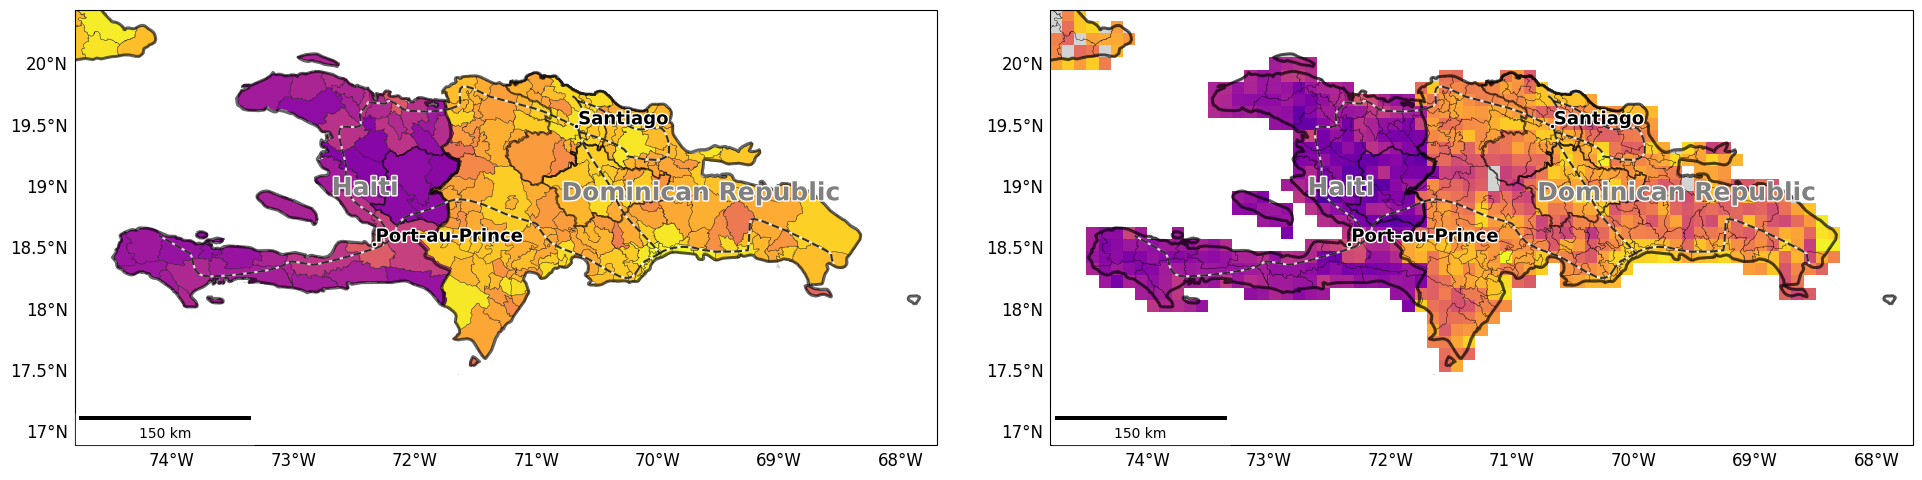

In [12]:
make_superzoom(left_bound, right_bound, top_bound, lower_bound,
              savepath = repo_dir + "figures/" + "superzoom_hispaniola.pdf",
              )

In [13]:
## Bay of bengal

left_bound = 84
right_bound = 102

top_bound = 26
lower_bound = 17

(90, 180)
[[0.60009263 0.60173528 0.5979452  ... 0.61093761 0.63466962 0.58685576]
 [0.59865842 0.61061337 0.59854942 ... 0.64122737 0.63904693 0.59207381]
 [0.59520991 0.64280373 0.61244812 ... 0.62417167 0.68979688 0.57766131]
 ...
 [       nan        nan        nan ... 0.8444186  0.8005705  0.78915033]
 [       nan        nan        nan ... 0.73676308 0.80366027 0.76413429]
 [       nan        nan        nan ... 0.74997403 0.78141861 0.71998425]]
Bangladesh
Myanmar


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Bangladesh
Myanmar


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizon

(<Figure size 2000x1300 with 2 Axes>,
 array([<GeoAxes: >, <GeoAxes: >], dtype=object))

/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the wa

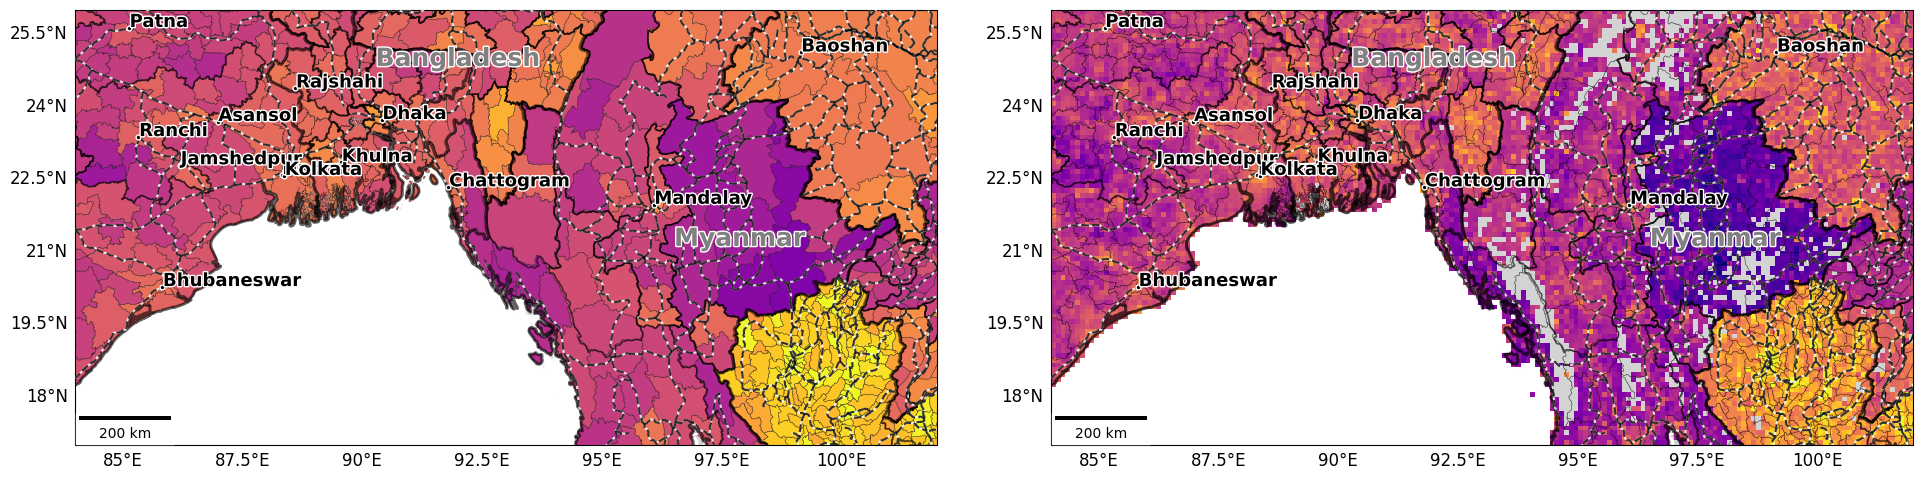

In [14]:
make_superzoom(left_bound, right_bound, top_bound, lower_bound,
              repo_dir + "figures/" + "superzoom_bengal.pdf",
              )

In [15]:
## Gulf of Guinea
left_bound = -4.4
right_bound = 11.8

top_bound = 9.7
lower_bound = 1.6

(81, 162)
[[0.3714634  0.41682367 0.38726342 ... 0.46437926 0.40674101 0.48760364]
 [0.49225244 0.38649207 0.4113722  ... 0.43580616 0.42344372 0.44258484]
 [0.4692847  0.38651322        nan ... 0.46067604 0.42163368 0.40389376]
 ...
 [       nan        nan        nan ... 0.55075725 0.56890596 0.58605689]
 [       nan        nan        nan ... 0.6646126  0.60458793 0.5522093 ]
 [       nan        nan        nan ... 0.7325394  0.59610279        nan]]
Benin
Ghana
Nigeria
Togo


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Benin
Ghana
Nigeria
Togo


/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizon

(<Figure size 2000x1300 with 2 Axes>,
 array([<GeoAxes: >, <GeoAxes: >], dtype=object))

/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/home/groups/smhsiang/venv/hdi/lib/python3.9/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the wa

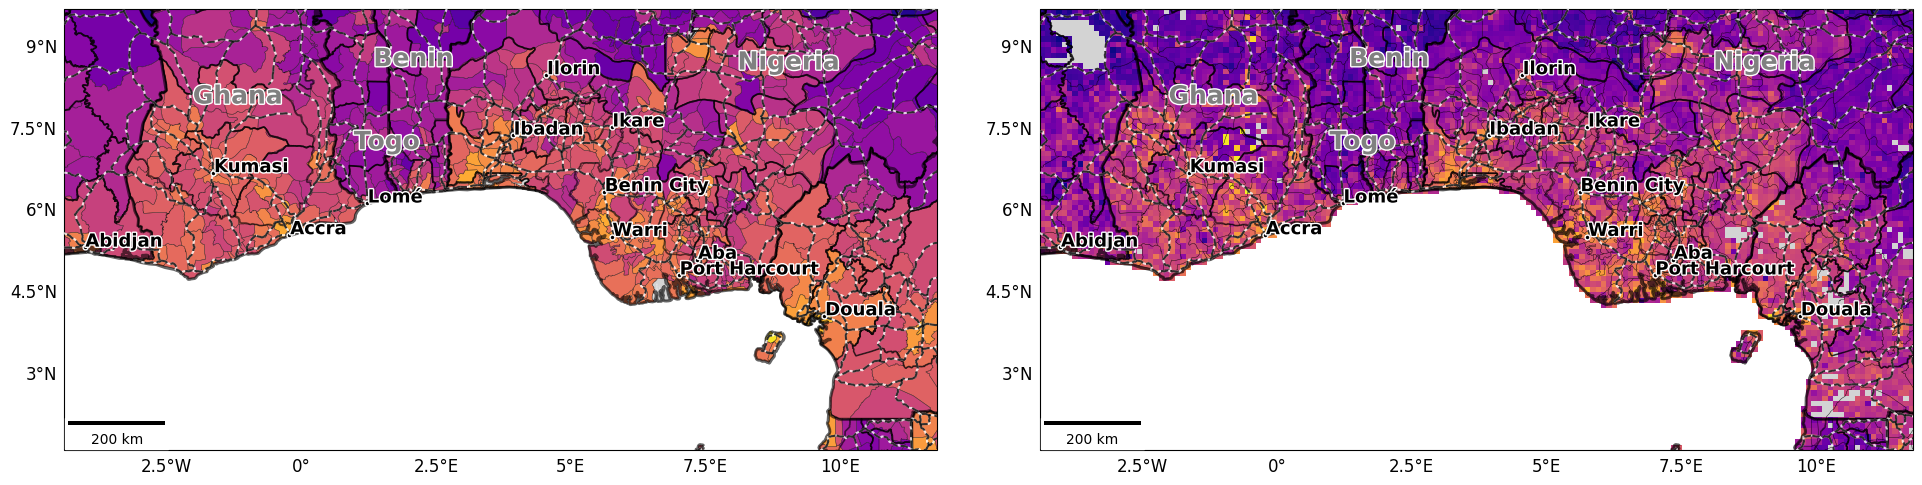

In [16]:
make_superzoom(left_bound, right_bound, top_bound, lower_bound,
               savepath = repo_dir + "figures/" + "superzoom_guinea.pdf",
              )

In [17]:
### Write colorbar

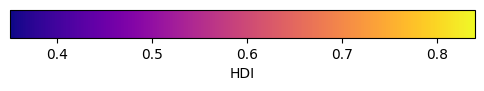

In [18]:
import matplotlib as mpl
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.6)

cmap = mpl.cm.plasma
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap,
                                norm=norm,
                                orientation='horizontal')
cb1.set_label('HDI')
fig.show()

fig.savefig(repo_dir + "figures/superzoom_cbar.pdf")